In [ ]:
import sys
from pathlib import Path

# Add src/ to Python path for local module imports
sys.path.insert(0, str(Path.cwd().parent / "src"))

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import json

import constants
from model_utils import *

from ast import literal_eval
from pathlib import Path

import matplotlib.cm as cm

from matplotlib.colors import LinearSegmentedColormap

import numpy as np

In [89]:
plt.style.use('ggplot')
sns.set_palette('hls', 18)
SPLIT = 'total'
model_type = constants.RectalCancerStagingData
base_dir = Path.cwd().parent

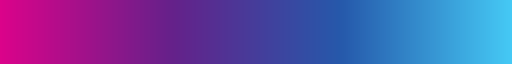

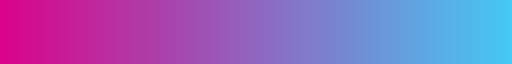

In [90]:
finomnia_palette = sns.color_palette(('#db038a',   # Pink
                                      '#66218a',   # Violet
                                      '#081c36',   # Dark Blue
                                      '#2659ab',   # blue
                                      '#45c9f5'))  # Light blue
finomnia_cmap = LinearSegmentedColormap.from_list("mio_cmap", [finomnia_palette[0], finomnia_palette[1], finomnia_palette[-2], finomnia_palette[-1]])
display(finomnia_cmap)
finomnia_cmap = LinearSegmentedColormap.from_list("mio_cmap", [finomnia_palette[0], finomnia_palette[-1]])
display(finomnia_cmap)


In [91]:
greens = sns.color_palette('Greens', 10)
blues = sns.color_palette('Blues', 10)
oranges = sns.color_palette('Oranges', 10)
reds = sns.color_palette('Reds', 10)
purples = sns.color_palette('Purples', 10)
greys = sns.color_palette('Greys', 10)

# Total performance

In [92]:
display(greens)
display(blues)
display(oranges)
display(reds)
display(purples)
display(greys)

[(0.9176931949250289, 0.9684275278738947, 0.901361014994233),
 (0.8459054209919262, 0.9399307958477509, 0.8228219915417148),
 (0.7558477508650518, 0.9033910034602076, 0.7290426758938869),
 (0.6436447520184544, 0.8561476355247981, 0.6197923875432525),
 (0.5185697808535179, 0.7983391003460207, 0.5150941945405614),
 (0.3827450980392157, 0.7332564398308343, 0.42737408688965783),
 (0.2452133794694348, 0.6602537485582468, 0.35695501730103807),
 (0.1566320645905421, 0.5657670126874279, 0.28608996539792386),
 (0.06082276047673972, 0.47958477508650516, 0.21599384851980008),
 (0.0, 0.38268358323721646, 0.15398692810457515)]

[(0.8978854286812764, 0.939038831218762, 0.977362552864283),
 (0.828881199538639, 0.8937639369473279, 0.954725105728566),
 (0.7506343713956171, 0.8478431372549019, 0.9282122260668974),
 (0.6325259515570935, 0.7976470588235294, 0.8868742791234141),
 (0.491764705882353, 0.7219684736639754, 0.8547789311803152),
 (0.36159938485198, 0.6427374086889658, 0.8165782391387928),
 (0.24816608996539793, 0.5618915801614763, 0.7709803921568628),
 (0.15072664359861593, 0.4644521337946943, 0.7207843137254902),
 (0.07481737793156479, 0.3732564398308343, 0.6552095347943099),
 (0.03137254901960784, 0.28161476355247983, 0.5582622068435218)]

[(0.9971703191080353, 0.9183391003460207, 0.8395078815840061),
 (0.9943406382160708, 0.8637293348712034, 0.7313802383698578),
 (0.9921568627450981, 0.7937254901960784, 0.5997693194925029),
 (0.9921568627450981, 0.6933333333333334, 0.4373702422145329),
 (0.9921568627450981, 0.5996309111880046, 0.3017916186082276),
 (0.9751787773933103, 0.5020069204152249, 0.17728565936178392),
 (0.9373471741637831, 0.40110726643598615, 0.0686966551326413),
 (0.8664821222606689, 0.3036678200692041, 0.015547866205305648),
 (0.7396078431372549, 0.24304498269896194, 0.008289119569396385),
 (0.6083967704728951, 0.19538638985005768, 0.012856593617839291)]

[(0.9971703191080353, 0.901361014994233, 0.8562860438292964),
 (0.9926028450595925, 0.8141330257593233, 0.7383775470972702),
 (0.9882352941176471, 0.7068512110726644, 0.6010149942329873),
 (0.9882352941176471, 0.5857900807381776, 0.46223760092272204),
 (0.9857285659361784, 0.4722798923490965, 0.34678969627066514),
 (0.9673356401384082, 0.34918877354863515, 0.24775086505190314),
 (0.9256286043829296, 0.22006920415224915, 0.1677047289504037),
 (0.8193310265282583, 0.11672433679354094, 0.12341407151095732),
 (0.7130949634755863, 0.0744636678200692, 0.0962552864282968),
 (0.579361783929258, 0.04244521337946944, 0.07361783929257976)]

[(0.951449442522107, 0.9446981930026913, 0.969519415609381),
 (0.9007612456747405, 0.8963936947327951, 0.9434063821607074),
 (0.8355247981545559, 0.8361707035755478, 0.9118800461361014),
 (0.7469434832756633, 0.7505420991926183, 0.8675893886966551),
 (0.6620530565167244, 0.653440984236832, 0.8126105344098424),
 (0.5771626297577854, 0.5628911956939638, 0.7645059592464436),
 (0.4948558246828143, 0.47598615916955017, 0.7219838523644752),
 (0.4298961937716263, 0.3460668973471741, 0.6540715109573241),
 (0.36764321414840445, 0.22592848904267587, 0.5955401768550557),
 (0.30648212226066895, 0.11035755478662054, 0.5411303344867359)]

[(0.9575547866205305, 0.9575547866205305, 0.9575547866205305),
 (0.9012072279892349, 0.9012072279892349, 0.9012072279892349),
 (0.8328950403690888, 0.8328950403690888, 0.8328950403690888),
 (0.7502191464821223, 0.7502191464821223, 0.7502191464821223),
 (0.6434140715109573, 0.6434140715109573, 0.6434140715109573),
 (0.5387158785082661, 0.5387158785082661, 0.5387158785082661),
 (0.440322952710496, 0.440322952710496, 0.440322952710496),
 (0.342883506343714, 0.342883506343714, 0.342883506343714),
 (0.22329873125720878, 0.22329873125720878, 0.22329873125720878),
 (0.10469819300269129, 0.10469819300269129, 0.10469819300269129)]

In [93]:
models_aesthetics = {
#    'most_frequent_and_mean':                    (greys[0], None, None),
#    'uniform_and_mean':                          (greys[2], None, None),
#    'stratified_and_mean':                       (greys[4], None, None),
#    'mistral_30':                       (reds[4], None, None),
    'Mistral Large 3':                  (reds[6], None, None),
    'GPT 4.1 Nano':                     (greens[0], None, None),
    'GPT 4.1 Nano few-shots':                     (greens[1], None, None),
    'GPT 4.1 Nano few-shots MMR':                     (greens[2], None, None),
    'GPT 4.1 Nano FT':               (greens[3], None, None),
    'GPT 4.1 Nano FT OS':  (greens[4], None, None),
    'GPT 4.1 Mini':                     (greens[5], None, None),
    'GPT 4.1':                          (greens[6], None, None),
    'GPT 4.1 FT':                          (greens[7], None, None),
#    'gpt_4_1_tuned_oversampling':       (greens[7], None, None),
#    'gpt_4_1_tuned_few_shots':          (greens[8], None, None),
#    'gpt_4_1_tuned_MMR':                (greens[9], None, None),
    'GPT 5.4 reasoning':                (blues[3], None, None),
    'Opus 4.6':                         (purples[5], None, None),
#    'opus_4_6_few_shots':               (purples[6], None, None),
#    'opus_4_6_MMR':                     (purples[7], None, None)
}
plot_models = list(models_aesthetics.keys())

In [94]:
plot_models

['Mistral Large 3',
 'GPT 4.1 Nano',
 'GPT 4.1 Nano few-shots',
 'GPT 4.1 Nano few-shots MMR',
 'GPT 4.1 Nano FT',
 'GPT 4.1 Nano FT OS',
 'GPT 4.1 Mini',
 'GPT 4.1',
 'GPT 4.1 FT',
 'GPT 5.4 reasoning',
 'Opus 4.6']

In [95]:
scores = pd.read_csv(base_dir / 'data' / 'metrics' / 'scores.csv')
scores.rename(
    columns={
        constants.OPENAI_GPT_4_1_NANO: 'GPT 4.1 Nano',
        f'{constants.OPENAI_GPT_4_1_NANO}_few-shots': 'GPT 4.1 Nano few-shots',
        f'{constants.OPENAI_GPT_4_1_NANO}_MMR': 'GPT 4.1 Nano few-shots MMR',
        constants.TUNED_GPT_4_1_NANO: 'GPT 4.1 Nano FT',
        constants.TUNED_GPT_4_1_NANO_OVERSAMPLE: 'GPT 4.1 Nano FT OS',
        constants.OPENAI_GPT_4_1_MINI: 'GPT 4.1 Mini',
        constants.OPENAI_GPT_4_1: 'GPT 4.1',
        constants.TUNED_GPT_4_1: 'GPT 4.1 FT',
        #constants.TUNED_GPT_4_1_OVERSAMPLING: 'gpt_4_1_tuned_oversampling',
        #f'few_shots_{constants.TUNED_GPT_4_1_OVERSAMPLING}': 'gpt_4_1_tuned_few_shots',
        #f'MMR_{constants.TUNED_GPT_4_1_OVERSAMPLING}': 'gpt_4_1_tuned_MMR',
        constants.OPENAI_GPT_5_4: 'GPT 5.4 reasoning',
        constants.MISTRAL_LARGE_3: 'Mistral Large 3',
        constants.CLAUDE_OPUS_4_6: 'Opus 4.6',
        #f'few_shots_{constants.CLAUDE_OPUS_4_6}': 'opus_4_6_few_shots',
        #f'MMR_{constants.CLAUDE_OPUS_4_6}': 'opus_4_6_MMR'
    },
    inplace=True
)


In [96]:
train_scores = scores[scores.split=='train']
validation_scores = scores[scores.split=='validation']
test_scores = scores[scores.split=='test']

if SPLIT == 'val-test':
    scores = pd.concat([validation_scores, test_scores], ignore_index=True)
elif SPLIT == 'test':
    scores = test_scores

scores = scores[['id']+plot_models]

print(len(scores))

315


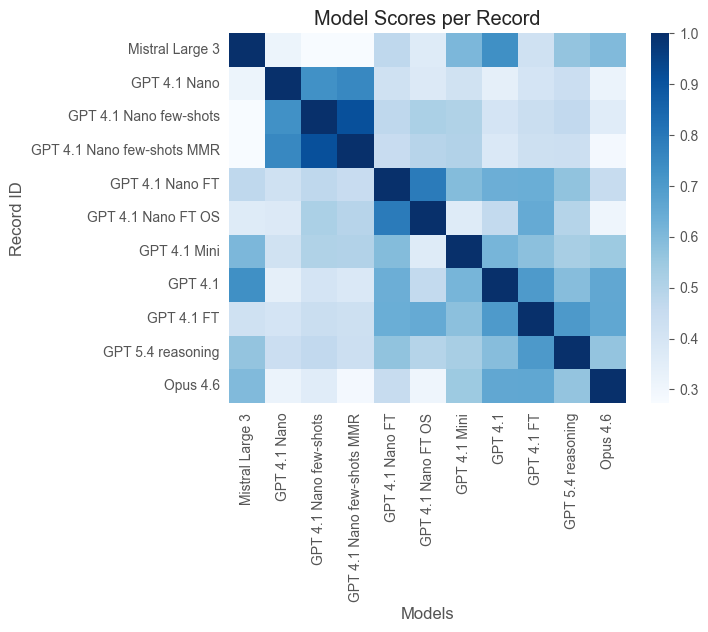

In [97]:
#sns.heatmap(scores.iloc[:, 1:].corr(), cmap=finomnia_cmap, annot=False)
sns.heatmap(scores.iloc[:, 1:].corr(), cmap='Blues', annot=False)

plt.title("Model Scores per Record")
plt.xlabel("Models")
plt.ylabel("Record ID")
plt.show()

Mistral Large 3                9.798999
GPT 4.1 Nano                   6.868369
GPT 4.1 Nano few-shots         7.462050
GPT 4.1 Nano few-shots MMR     7.203294
GPT 4.1 Nano FT                9.573757
GPT 4.1 Nano FT OS            10.641890
GPT 4.1 Mini                   9.283797
GPT 4.1                        9.947368
GPT 4.1 FT                    11.366663
GPT 5.4 reasoning             10.800555
Opus 4.6                       9.735085
dtype: float64


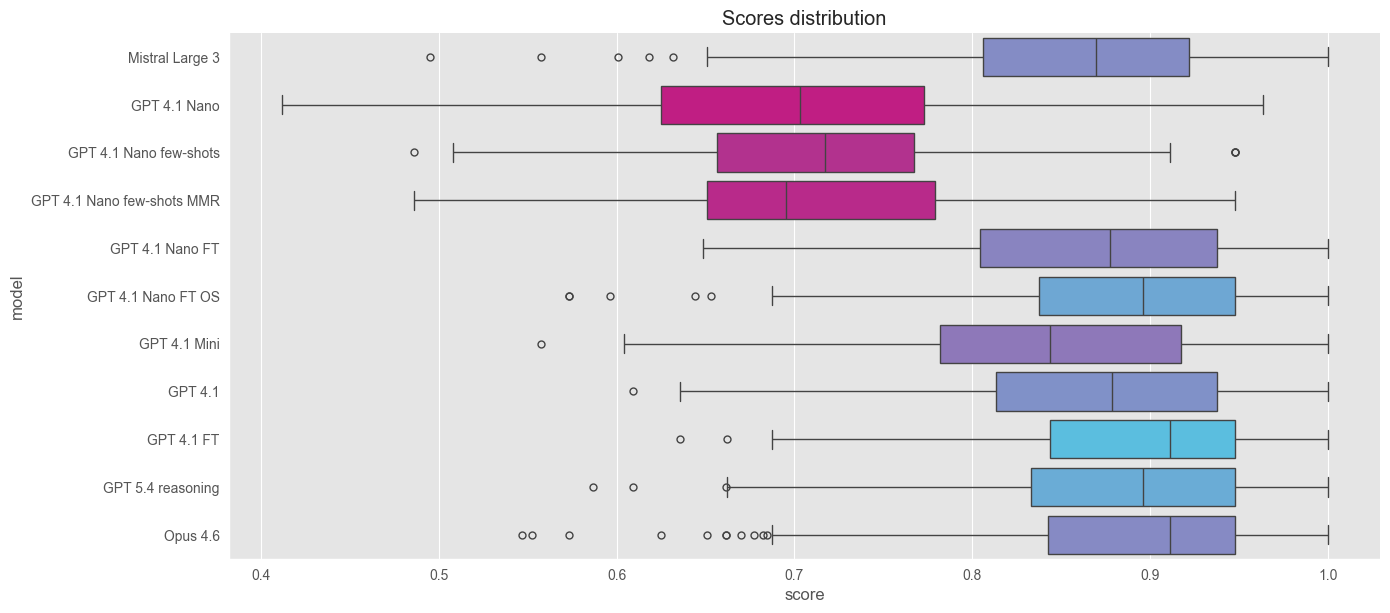

In [98]:
df_sharpe_scores = scores.drop(columns='id')
series_sharpe_scores = df_sharpe_scores.mean() / df_sharpe_scores.std()
#series_sharpe_scores = df_sharpe_scores.median() / df_sharpe_scores.std()

# Normalizziamo gli Sharpe tra 0 e 1
norm_scores = (series_sharpe_scores - series_sharpe_scores.min()) / (series_sharpe_scores.max() - series_sharpe_scores.min())



print(series_sharpe_scores)
palette_sharpe_scores = {model: finomnia_cmap(norm_scores[model]) for model in series_sharpe_scores.index}

scores_melted = scores.melt(id_vars='id', var_name='model', value_name='score')
sns.catplot(data=scores_melted, y="model", x="score", kind='box', height=6, aspect=21/9, palette=palette_sharpe_scores, hue='model')
plt.title("Scores distribution")
plt.show()

# Fields performance

In [99]:
target_columns = model_type.model_fields.keys()

reg_fields = get_regression_fields(model_type)
cl_fields = get_classification_fields(model_type)
mc_fields = get_multiple_choice_fields(model_type)
bc_fields = get_binary_classification_fields(model_type)
label_to_id_map = create_label_to_id_map(model_type)
mc_fields_estesi = get_extended_multiple_choice_fields(model_type)

In [100]:
##############
# Load metrics
##############

dfs = dict()

#bl_most_frequent = pd.read_csv(base_dir / 'data' / 'metrics' / 'metrics_baseline_most_frequent.csv', index_col=[0, 1])
#dfs['most_frequent_and_mean'] = bl_most_frequent

#bl_uniform = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_baseline_uniform.csv', index_col=[0, 1])
#dfs['uniform_and_mean'] = bl_uniform

#bl_stratified = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_baseline_stratified.csv', index_col=[0, 1])
#dfs['stratified_and_mean'] = bl_stratified
#dfs['mean'] = bl_uniform.loc[(reg_fields, ), :]

#mistral_30 = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_mistral_30.csv', index_col=[0, 1])
#dfs['mistral_30'] = mistral_30

gpt_4_1_nano = pd.read_csv(base_dir / 'data' / 'metrics' /  'new_metrics_gpt-4.1-nano.csv', index_col=[0, 1])
dfs['GPT 4.1 Nano'] = gpt_4_1_nano

gpt_4_1_nano_few_shots = pd.read_csv(base_dir / 'data' / 'metrics' /  'new_metrics_gpt-4.1-nano_few-shots.csv', index_col=[0, 1])
dfs['GPT 4.1 Nano few-shots'] = gpt_4_1_nano_few_shots

gpt_4_1_nano_mmr = pd.read_csv(base_dir / 'data' / 'metrics' /  'new_metrics_gpt-4.1-nano_MMR.csv', index_col=[0, 1])
dfs['GPT 4.1 Nano few-shots MMR'] = gpt_4_1_nano_mmr

gpt_4_1_nano_ft = pd.read_csv(base_dir / 'data' / 'metrics' /  'new_metrics_gpt-4.1-nano_FT.csv', index_col=[0, 1])
dfs['GPT 4.1 Nano FT'] = gpt_4_1_nano_ft

gpt_4_1_nano_ft_os = pd.read_csv(base_dir / 'data' / 'metrics' /  'new_metrics_gpt-4.1-nano_FT_OS.csv', index_col=[0, 1])
dfs['GPT 4.1 Nano FT OS'] = gpt_4_1_nano_ft_os

#gpt_4_1_nano_tuned_oversampling = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_gpt-4.1-nano-tuned-oversampling.csv', index_col=[0, 1])
#dfs['gpt_4_1_nano_tuned_oversampling'] = gpt_4_1_nano_tuned_oversampling

gpt_4_1_mini = pd.read_csv(base_dir / 'data' / 'metrics' /  'new_metrics_gpt-4.1-mini.csv', index_col=[0, 1])
dfs['GPT 4.1 Mini'] = gpt_4_1_mini

gpt_4_1 = pd.read_csv(base_dir / 'data' / 'metrics' /  'new_metrics_gpt-4.1.csv', index_col=[0, 1])
dfs['GPT 4.1'] = gpt_4_1

gpt_4_1_ft = pd.read_csv(base_dir / 'data' / 'metrics' /  'new_metrics_gpt-4.1_FT.csv', index_col=[0, 1])
dfs['GPT 4.1 FT'] = gpt_4_1_ft

#gpt_4_1_tuned_oversampling = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_gpt-4.1-tuned-oversampling.csv', index_col=[0, 1])
#dfs['gpt_4_1_tuned_oversampling'] = gpt_4_1_tuned_oversampling

#gpt_4_1_tuned_MMR = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_gpt-4.1-tuned-MMR.csv', index_col=[0, 1])
#dfs['gpt_4_1_tuned_MMR'] = gpt_4_1_tuned_MMR

#gpt_4_1_tuned_few_shots = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_gpt-4.1-tuned-similar_examples.csv', index_col=[0, 1])
#dfs['gpt_4_1_tuned_few_shots'] = gpt_4_1_tuned_few_shots

gpt_5_4 = pd.read_csv(base_dir / 'data' / 'metrics' /  'new_metrics_gpt-5.4_reasoning.csv', index_col=[0, 1])
dfs['GPT 5.4 reasoning'] = gpt_5_4

mistral_large_3 = pd.read_csv(base_dir / 'data' / 'metrics' /  'new_metrics_mistral-large-3.csv', index_col=[0, 1])
dfs['Mistral Large 3'] = mistral_large_3

opus_4_6 = pd.read_csv(base_dir / 'data' / 'metrics' /  'new_metrics_opus-4.6.csv', index_col=[0, 1])
dfs['Opus 4.6'] = opus_4_6

#opus_4_6_few_shots = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_opus-4.6_similar_examples.csv', index_col=[0, 1])
#dfs['opus_4_6_few_shots'] = opus_4_6_few_shots

#opus_4_6_MMR = pd.read_csv(base_dir / 'data' / 'metrics' /  'metrics_opus-4.6_MMR.csv', index_col=[0, 1])
#dfs['opus_4_6_MMR'] = opus_4_6_MMR

In [101]:
df_list = []
for model in plot_models:
    frame = dfs[model]
    frame = frame.loc[(slice(None), SPLIT), :]
    frame = frame.reset_index()
    frame['model'] = model
    df_list.append(frame)
df_metrics = pd.concat(df_list, ignore_index=True)

## Average on all fields

In [102]:
def plot_grouped_barchart(fields: list[str], models: list[str], metric: str = 'f1_macro', df_metrics=df_metrics) -> None:
    df_plot = df_metrics[
        (df_metrics['field'].isin(fields)) &
        (df_metrics['model'].isin(models))
    ]
    palette = {m: models_aesthetics[m][0] for m in models}
    plt.figure(figsize=(14, 6))
    ax = sns.barplot(data=df_plot, x='field', y=metric, hue='model', hue_order=models, palette=palette)
    for container, model in zip(ax.containers, models):
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=8)
        hatch = models_aesthetics[model][1]
        for bar in container:
            if hatch is not None:
                bar.set_hatch(hatch)
                bar.set_edgecolor(models_aesthetics[model][2])
            else:
                bar.set_edgecolor('white')
    ax.set(xlabel=None)
    ax.set_title(metric, pad=70)
    # Aggiorna gli handle della legenda con gli hatch
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        handle.set_hatch(models_aesthetics[label][1])

    ax.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncols=6, framealpha=0.8, fontsize='small')
    #plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

In [103]:
f1_dataframe = df_metrics.pivot(index='field', columns='model', values='f1_macro')

f1_fields = mc_fields + bc_fields + cl_fields
f1_dataframe = f1_dataframe.loc[f1_fields]
f1_dataframe = f1_dataframe[plot_models]

series_sharpe = f1_dataframe.mean() / f1_dataframe.std()
#series_sharpe = df_sharpe.median() / df_sharpe.std()
print(series_sharpe)

# Normalizziamo gli Sharpe tra 0 e 1
norm = (series_sharpe - series_sharpe.min()) / (series_sharpe.max() - series_sharpe.min())

model
Mistral Large 3               4.782004
GPT 4.1 Nano                  3.136820
GPT 4.1 Nano few-shots        2.515861
GPT 4.1 Nano few-shots MMR    2.552808
GPT 4.1 Nano FT               5.123134
GPT 4.1 Nano FT OS            7.035138
GPT 4.1 Mini                  4.588816
GPT 4.1                       5.283346
GPT 4.1 FT                    6.523017
GPT 5.4 reasoning             4.951973
Opus 4.6                      6.738482
dtype: float64


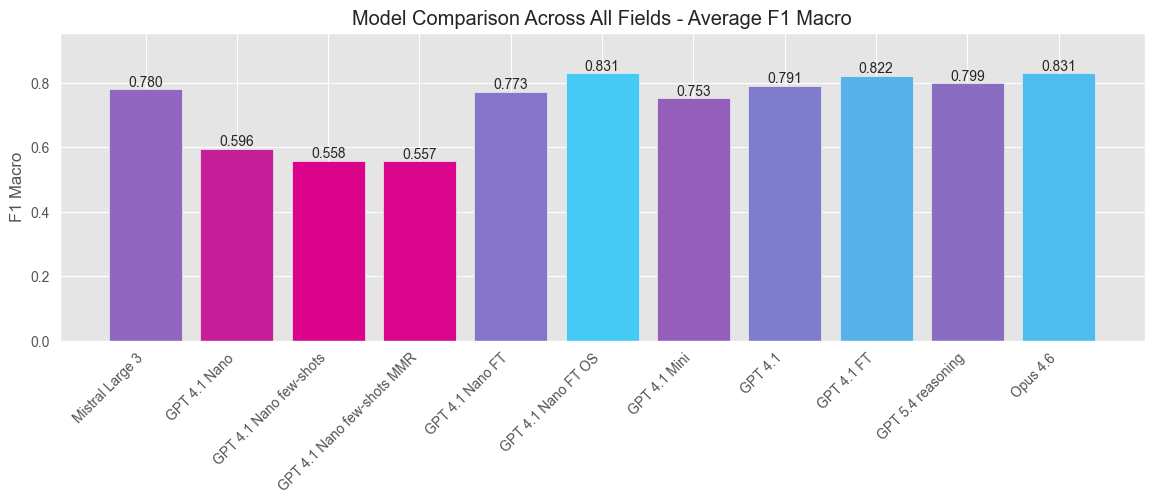

In [104]:
# Compute F1 means in a vectorized, readable way
f1_average = f1_dataframe.mean()
    
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(f1_average.index, f1_average.values, color=finomnia_cmap(norm))

# Add value labels on top of each bar
for bar, value in zip(bars, f1_average):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
        )
plt.xticks(rotation=45, ha="right")
ax.set_ylabel("F1 Macro")
ax.set_title("Model Comparison Across All Fields - Average F1 Macro")
ax.set_ylim(0, max(f1_average) * 1.15)

plt.show()

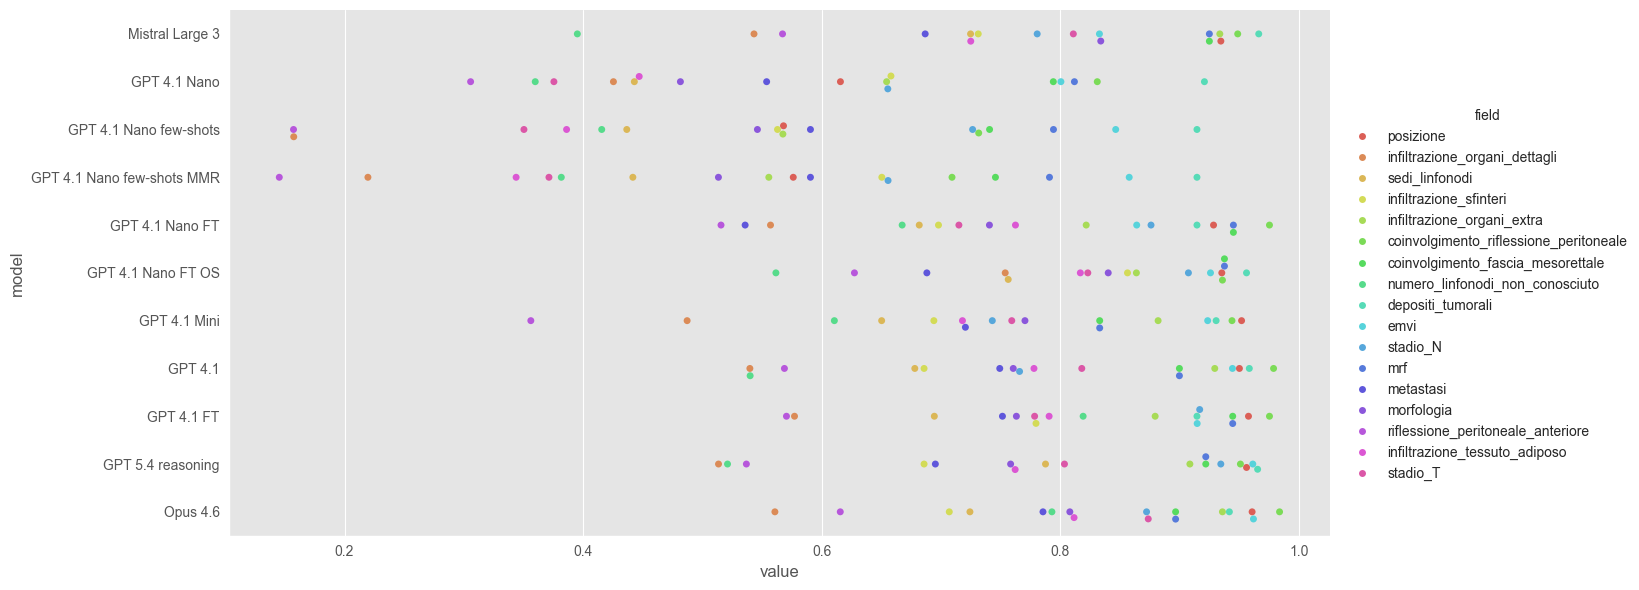

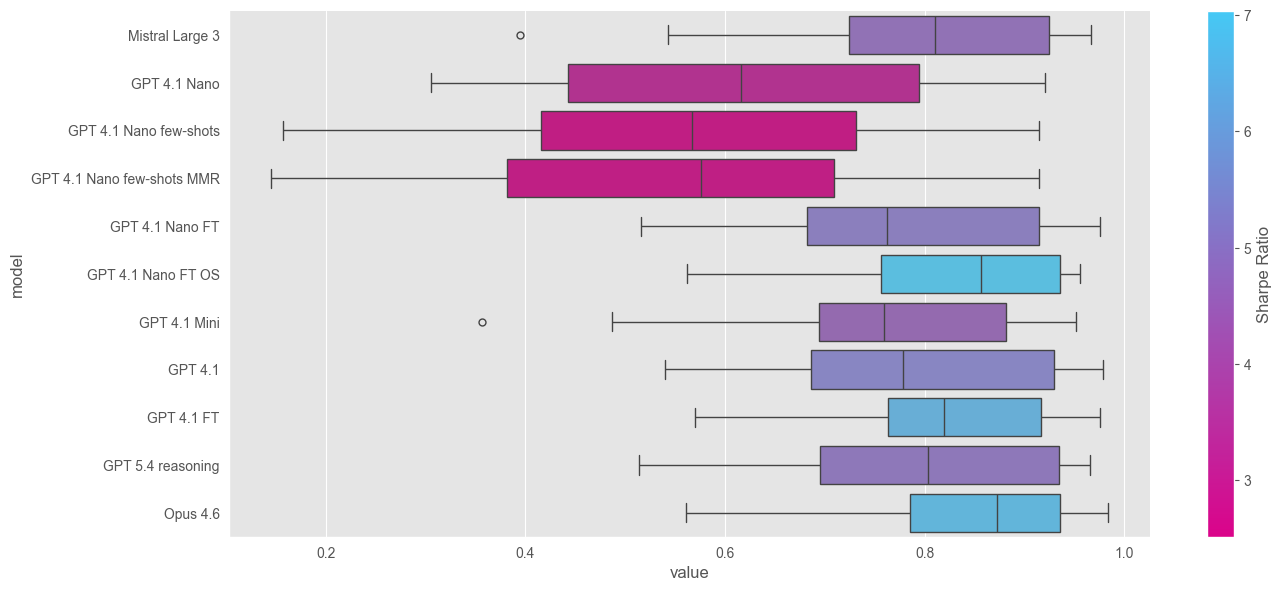

In [105]:
f1_dataframe = f1_dataframe.reset_index().melt('field', var_name='model')
sns.catplot(data=f1_dataframe, y="model", x="value", kind='swarm', hue='field', height=6, aspect=21/9)

# Scegli una colormap continua
palette_sharpe = {model: finomnia_cmap(norm[model]) for model in series_sharpe.index}
g = sns.catplot(data=f1_dataframe, x="value", y="model", height=6, aspect=21/9, kind='box',
            #order=series_sharpe.sort_values().index,
            palette=palette_sharpe, hue='model', legend=False)
fig = g.figure
sm = cm.ScalarMappable(
    cmap=finomnia_cmap,
    norm=plt.Normalize(series_sharpe.min(), series_sharpe.max())
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=g.axes, label="Sharpe Ratio")


plt.show()


## Multi-class fields

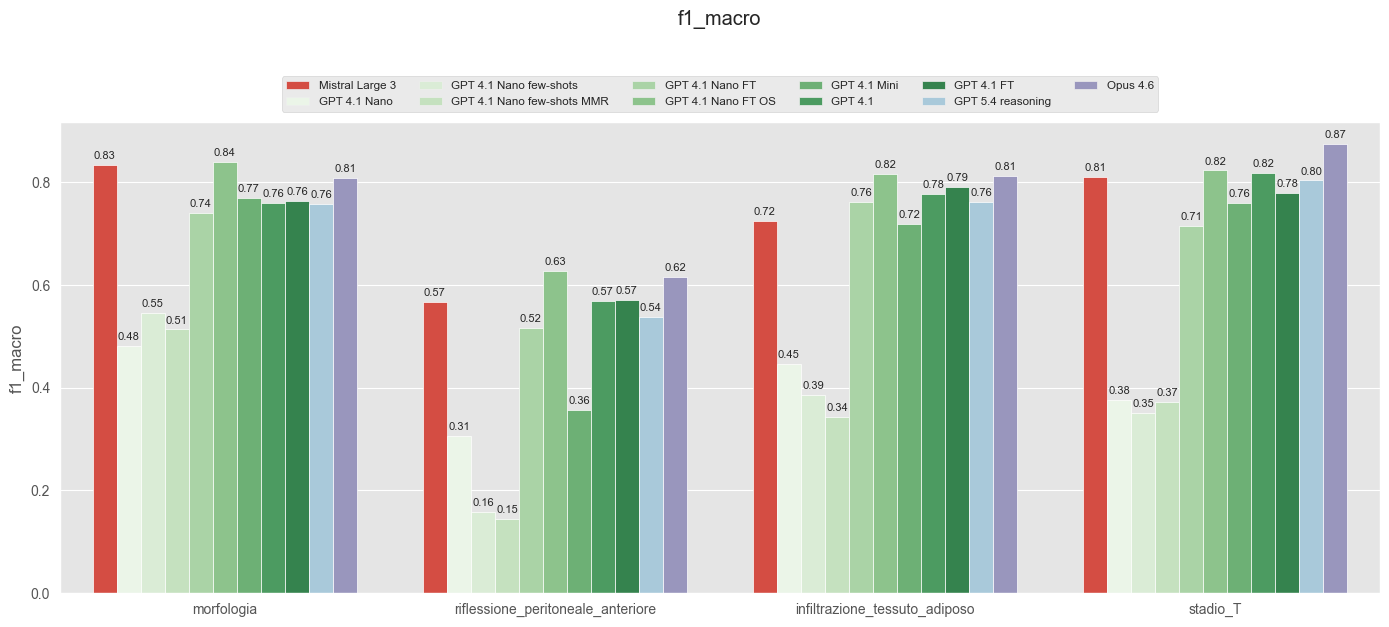

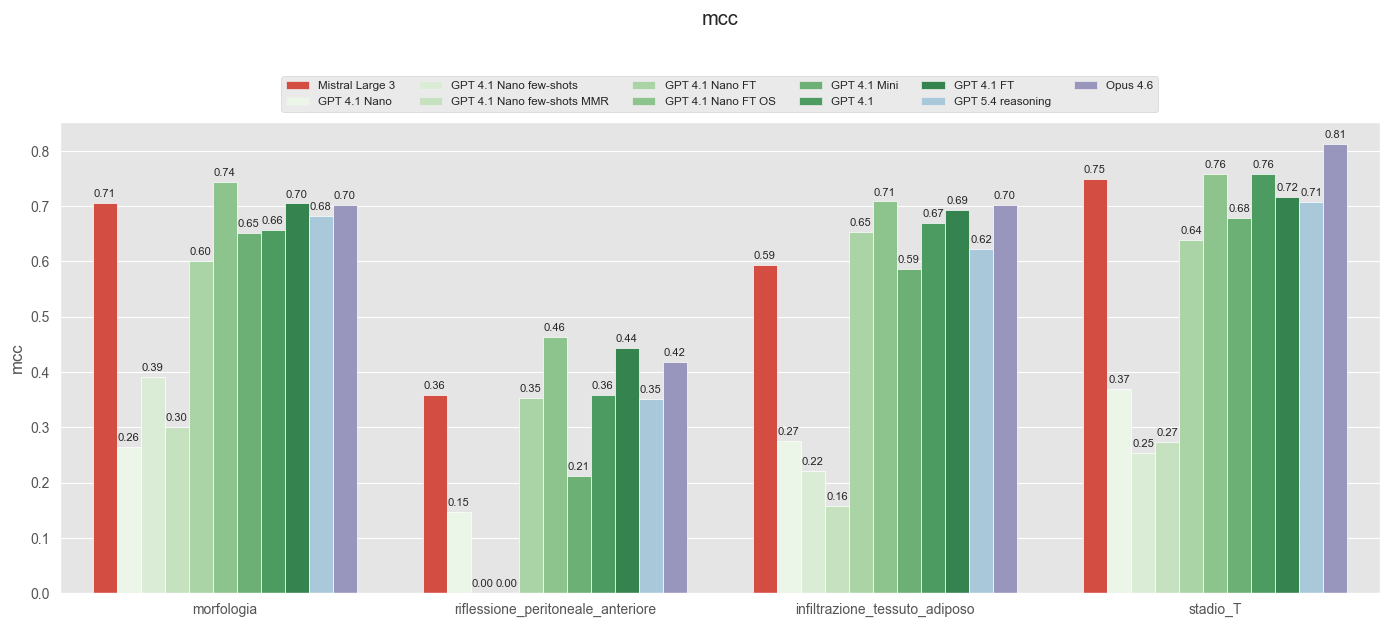

In [106]:
plot_fields = cl_fields

plot_grouped_barchart(plot_fields, plot_models)
plot_grouped_barchart(plot_fields, plot_models, metric='mcc')

## Binary fields

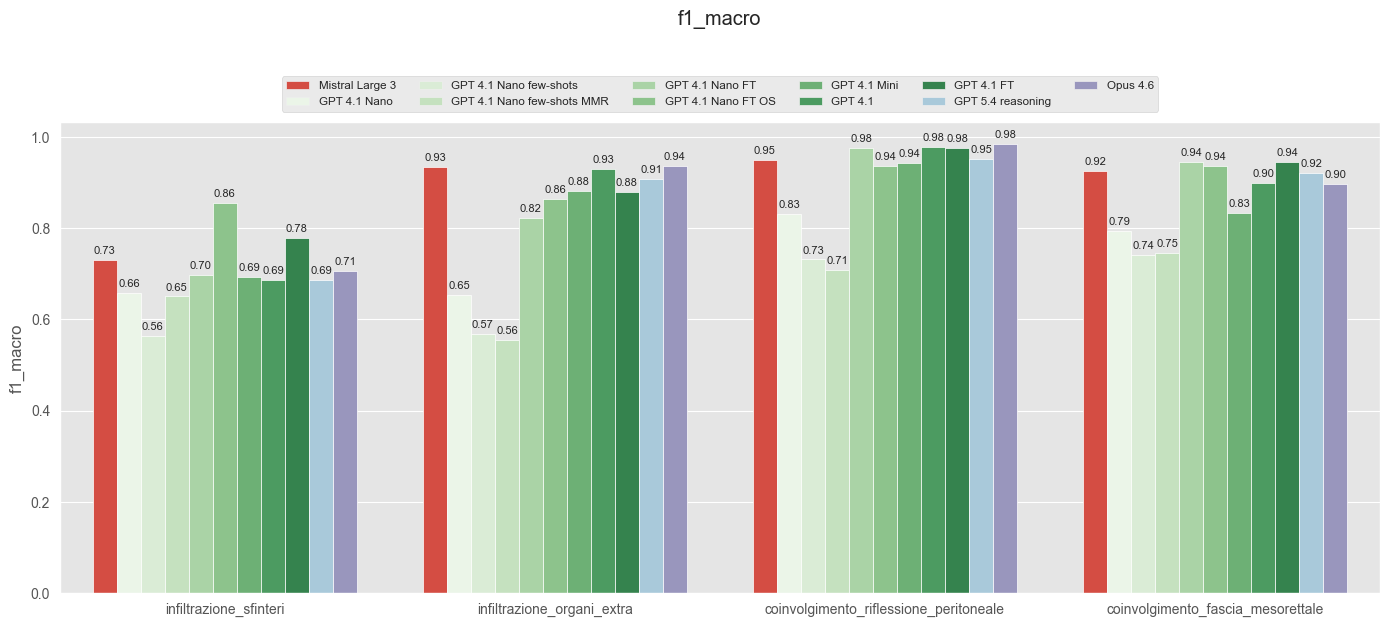

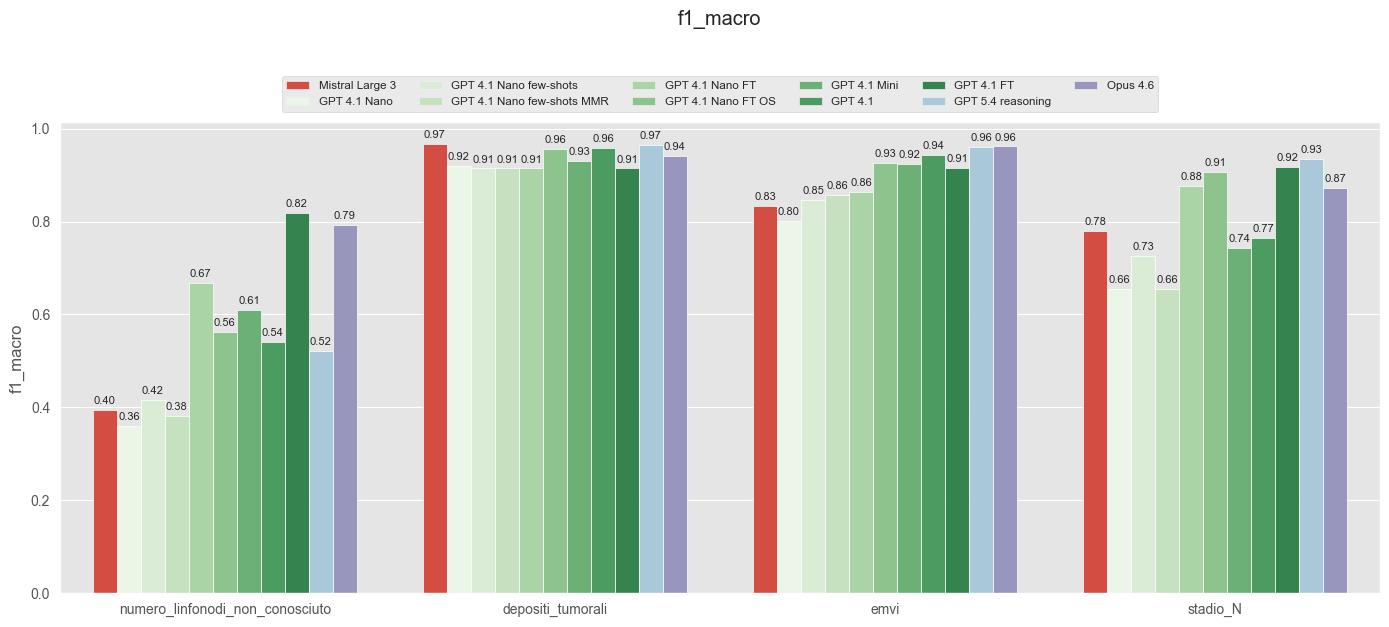

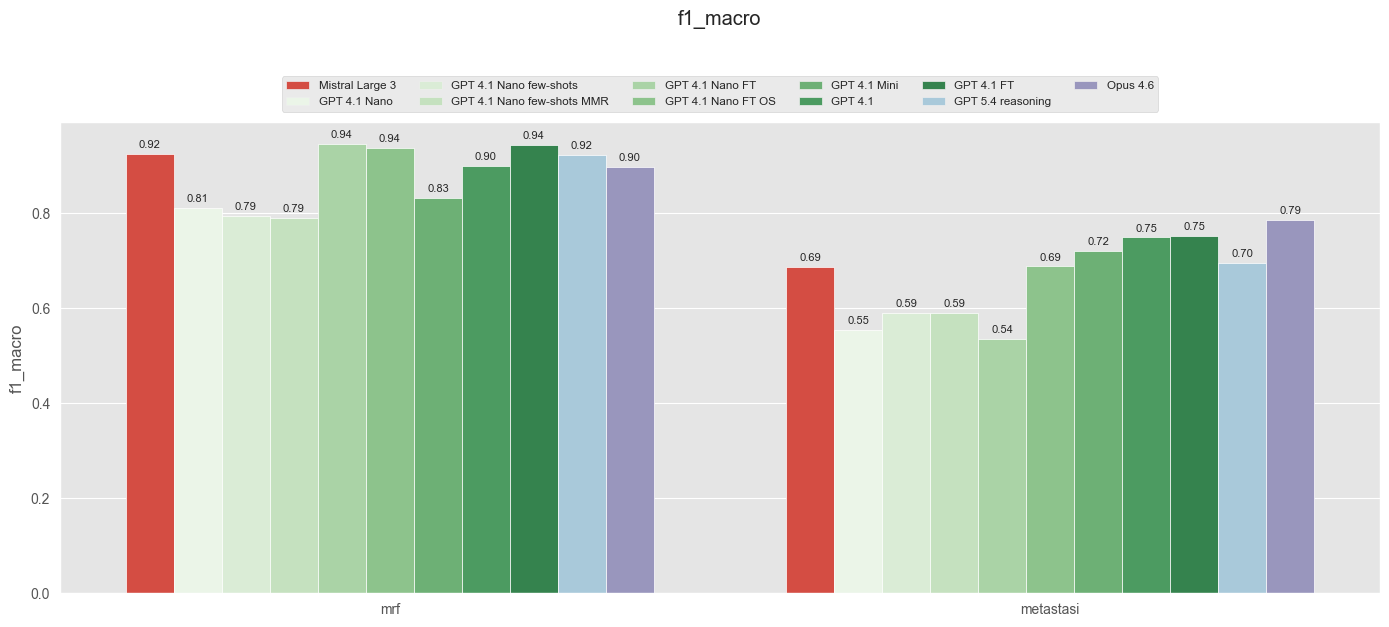

In [107]:
plot_fields = bc_fields[:4]
plot_grouped_barchart(plot_fields, plot_models)
#plot_grouped_barchart(plot_fields, plot_models, metric='mcc')

plot_fields = bc_fields[4:8]
plot_grouped_barchart(plot_fields, plot_models)
#plot_grouped_barchart(plot_fields, plot_models, metric='mcc')

plot_fields = bc_fields[8:]
plot_grouped_barchart(plot_fields, plot_models)
#plot_grouped_barchart(plot_fields, plot_models, metric='mcc')

## Multilabel fields

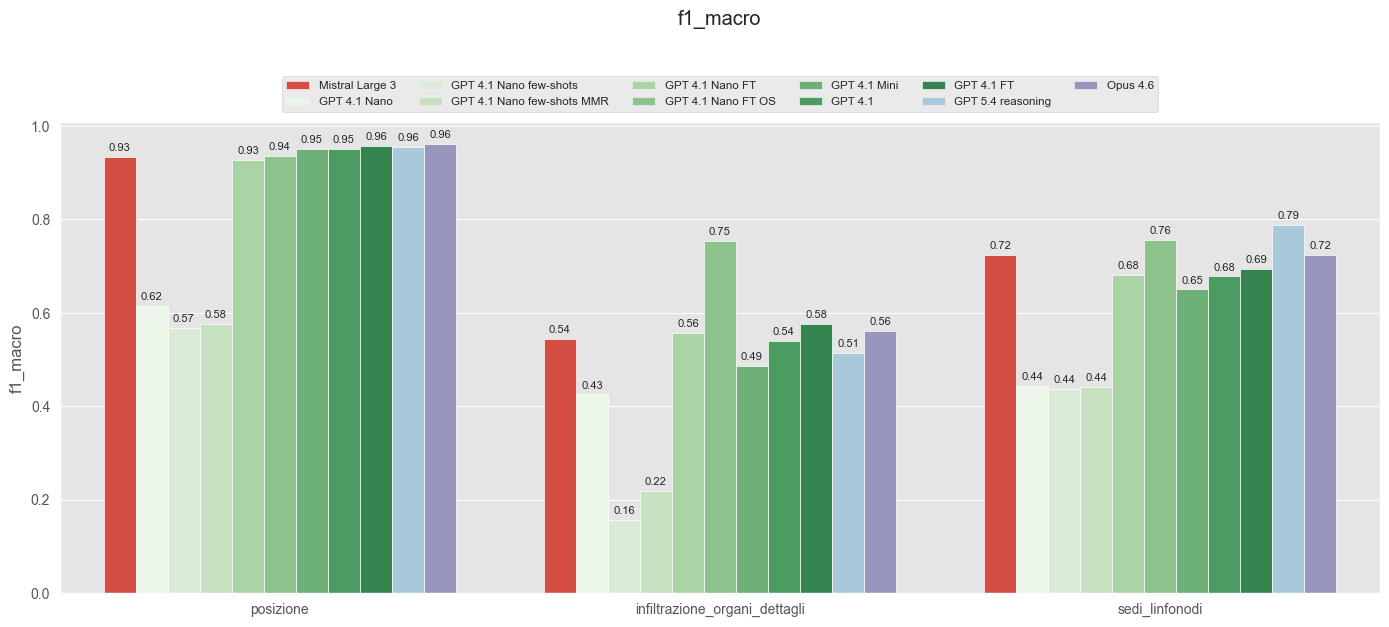

In [108]:
plot_fields = mc_fields

plot_grouped_barchart(plot_fields, plot_models)
#plot_grouped_barchart(plot_fields, plot_models, metric='f1_samples')

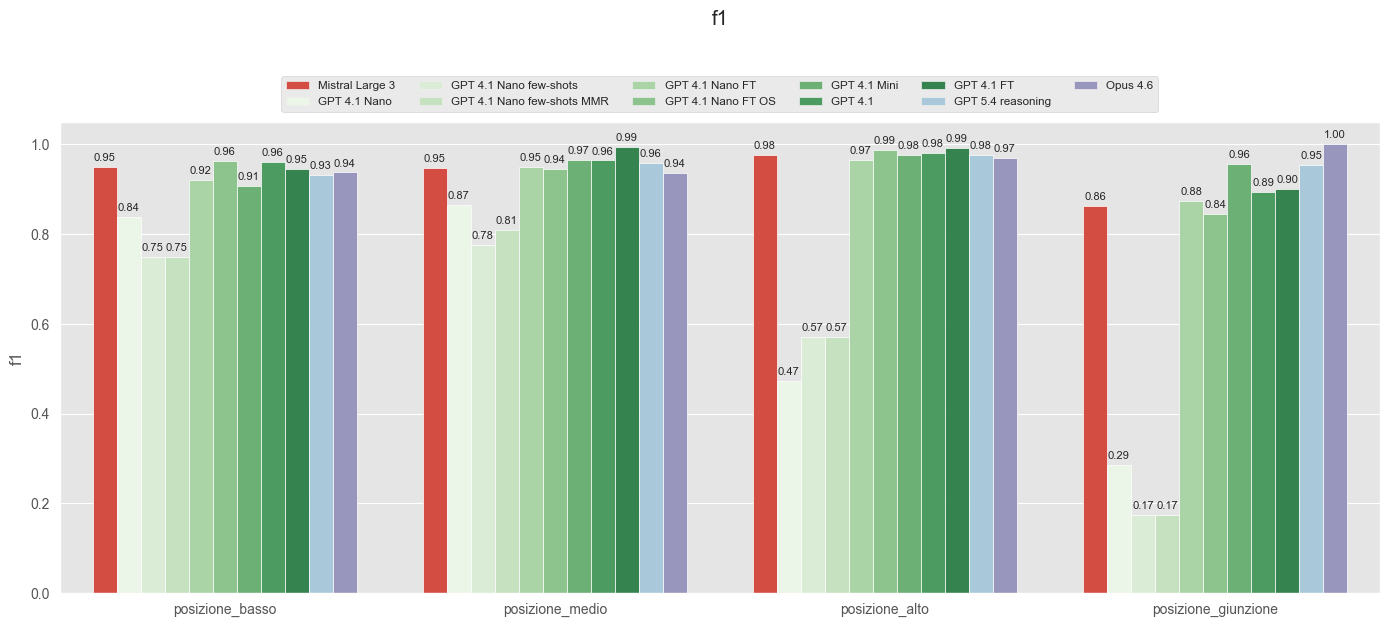

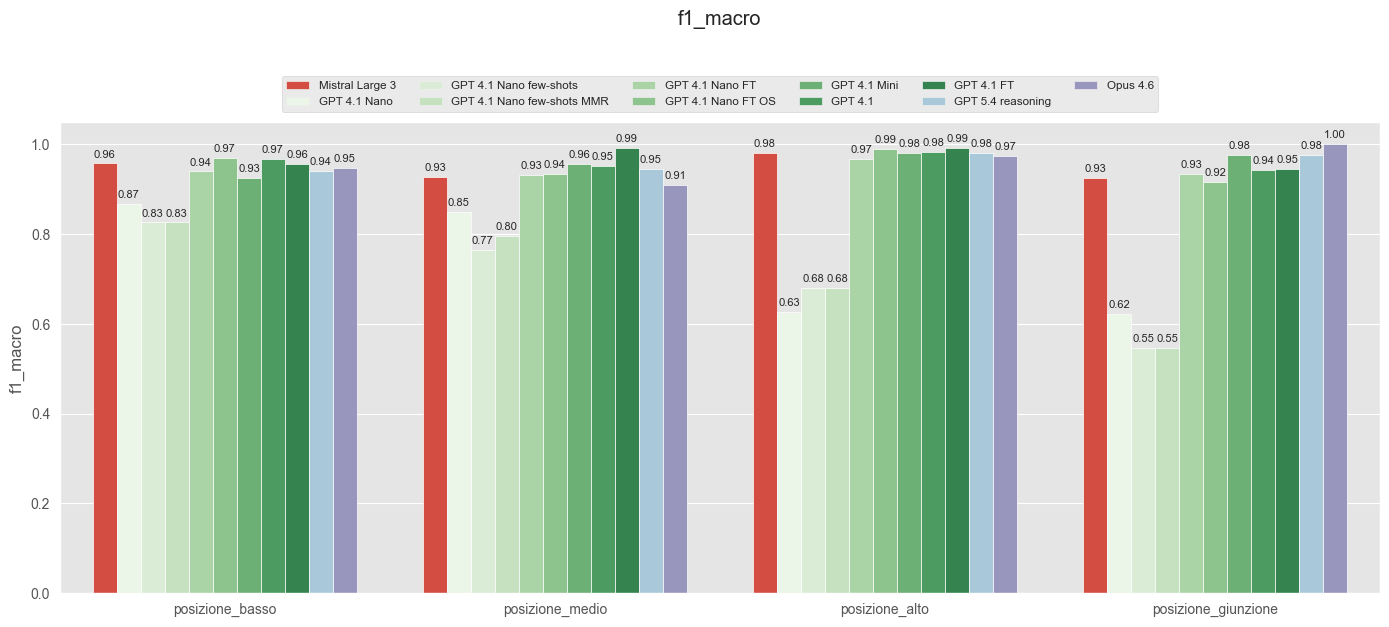

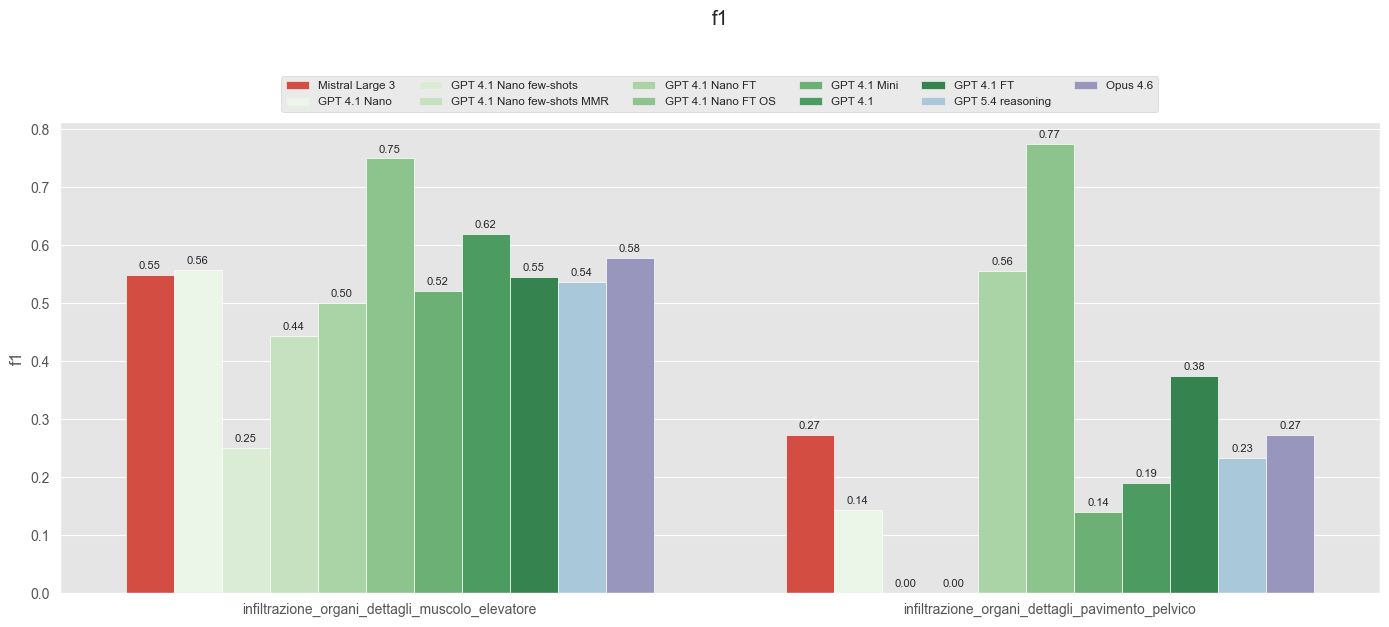

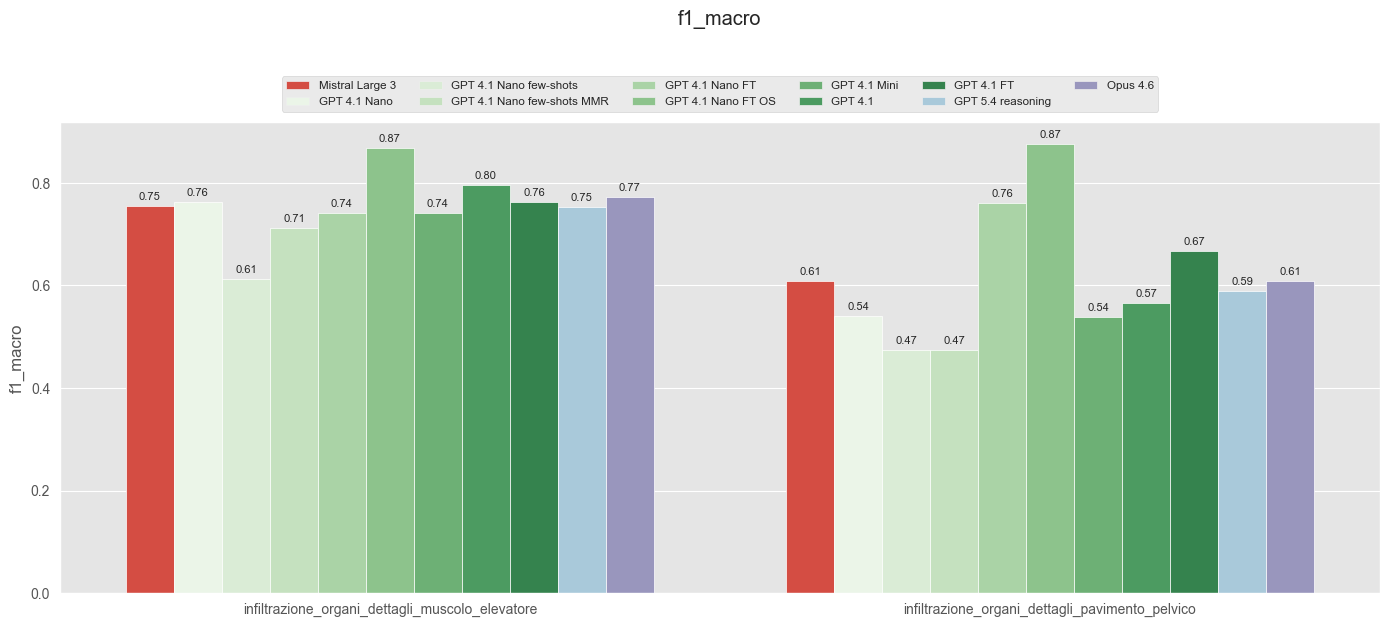

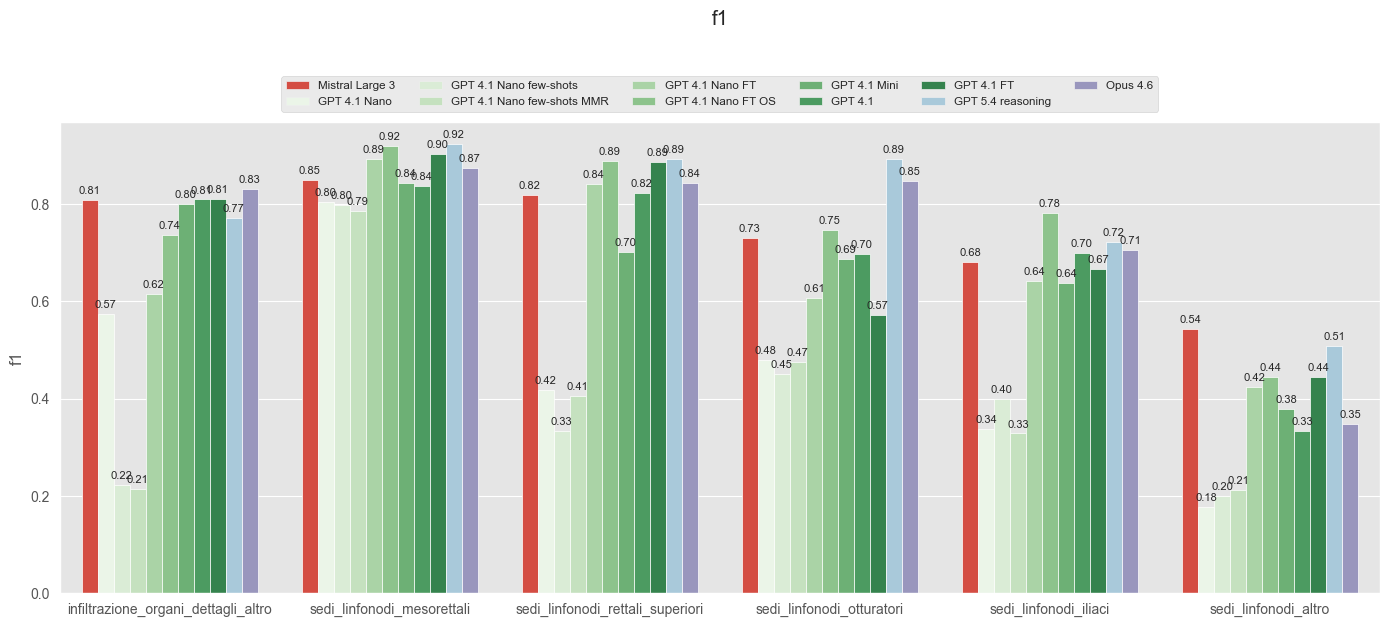

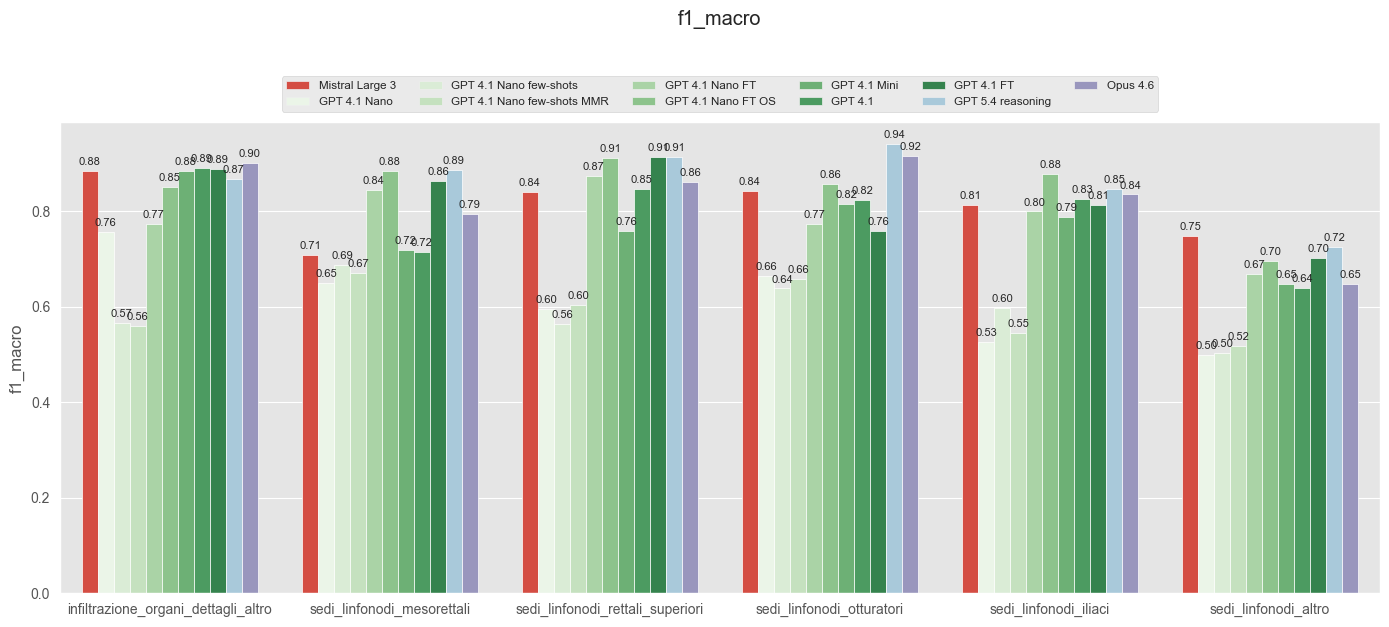

In [109]:
plot_fields = mc_fields_estesi[:4]

plot_grouped_barchart(plot_fields, plot_models, metric='f1')
plot_grouped_barchart(plot_fields, plot_models, metric='f1_macro')

plot_fields = mc_fields_estesi[4:6]

plot_grouped_barchart(plot_fields, plot_models, metric='f1')
plot_grouped_barchart(plot_fields, plot_models, metric='f1_macro')

plot_fields = mc_fields_estesi[6:]

plot_grouped_barchart(plot_fields, plot_models, metric='f1')
plot_grouped_barchart(plot_fields, plot_models, metric='f1_macro')

## Regression fields

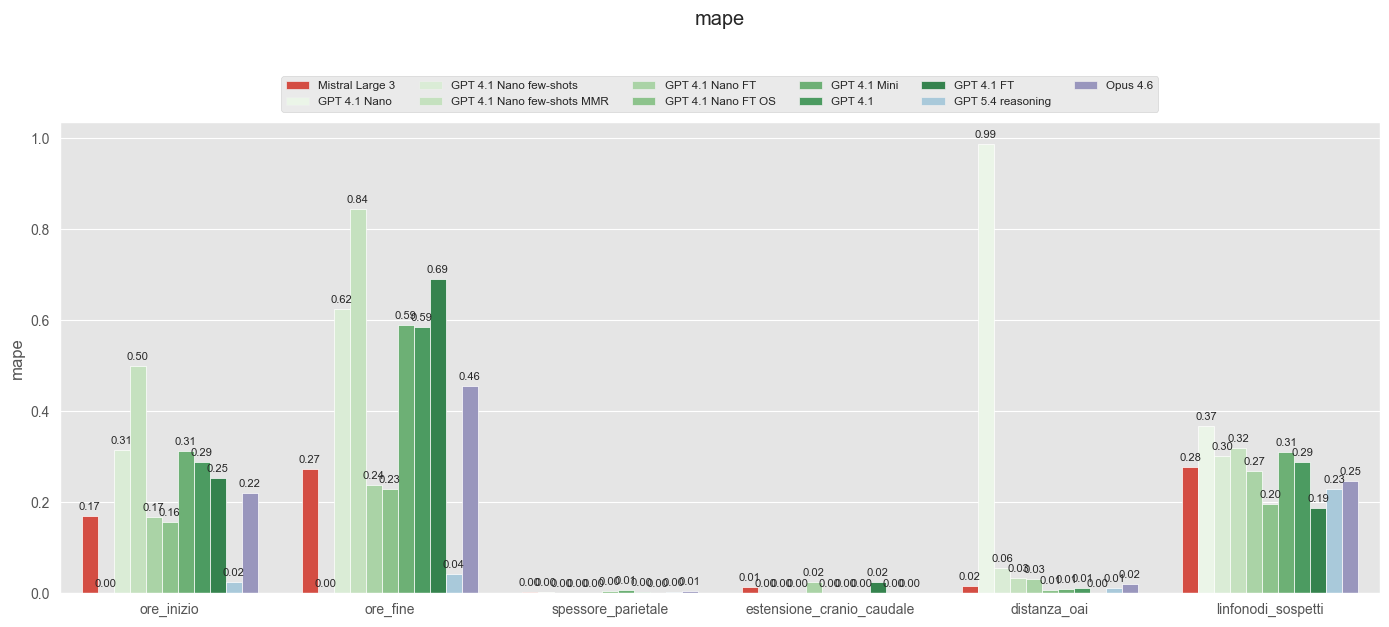

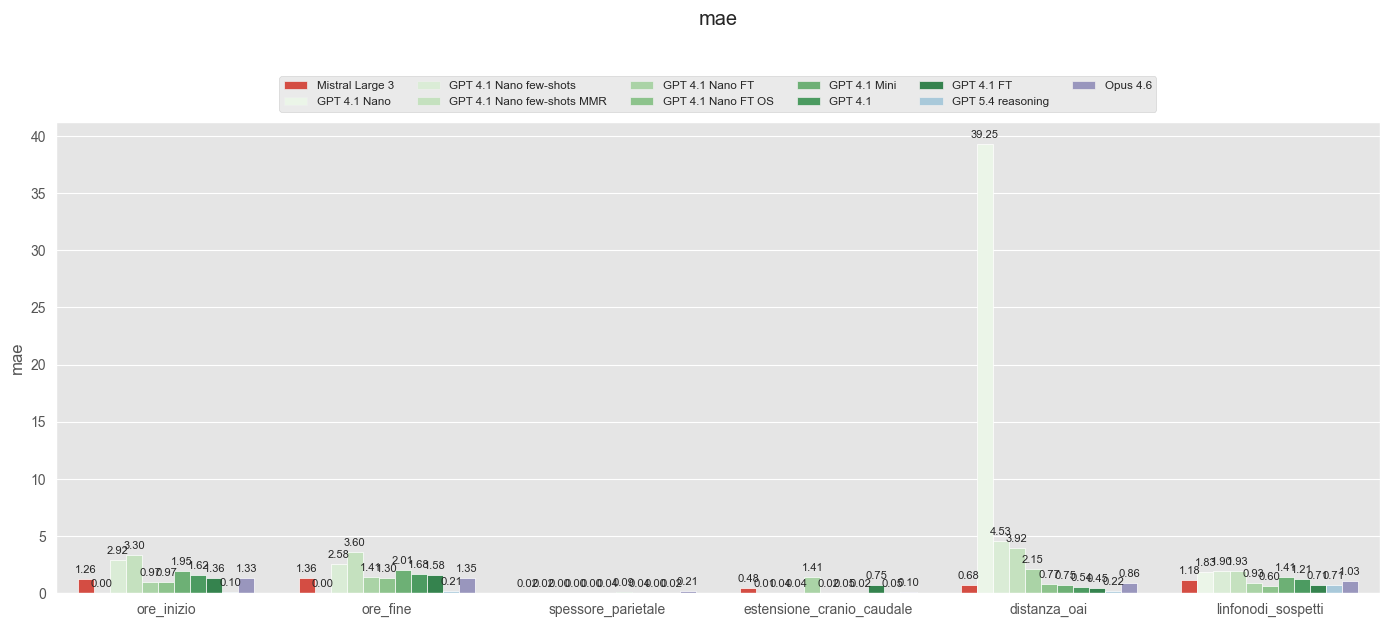

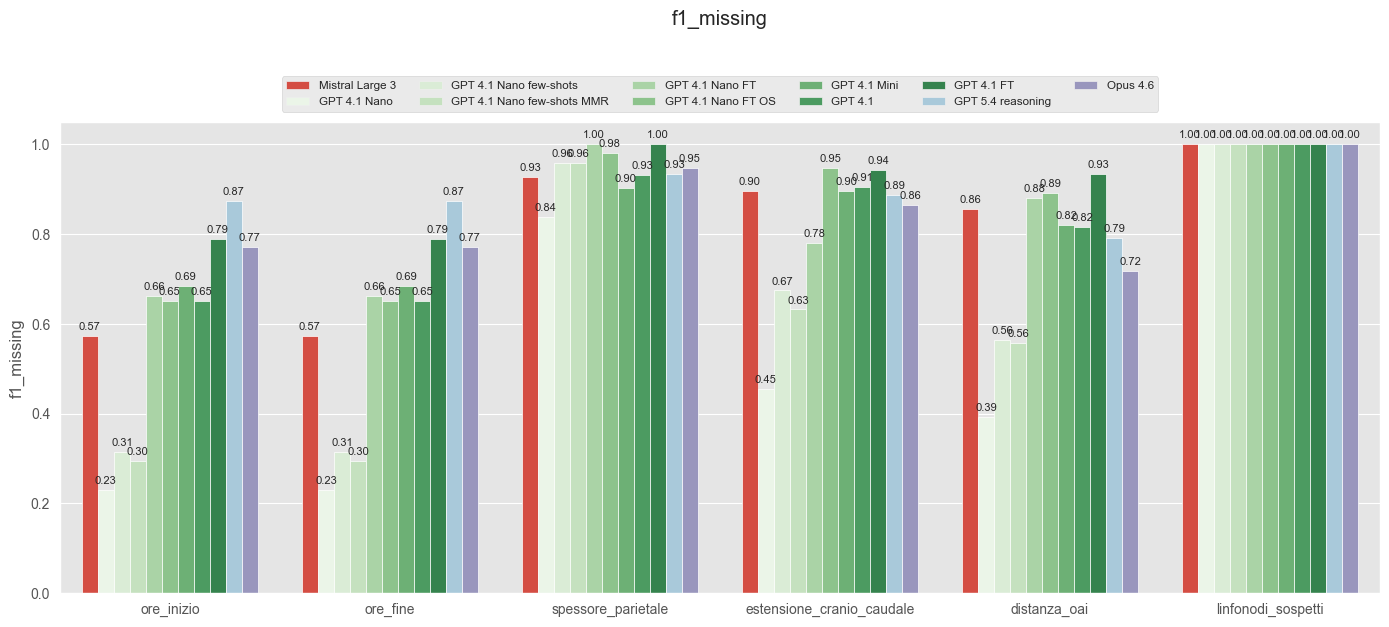

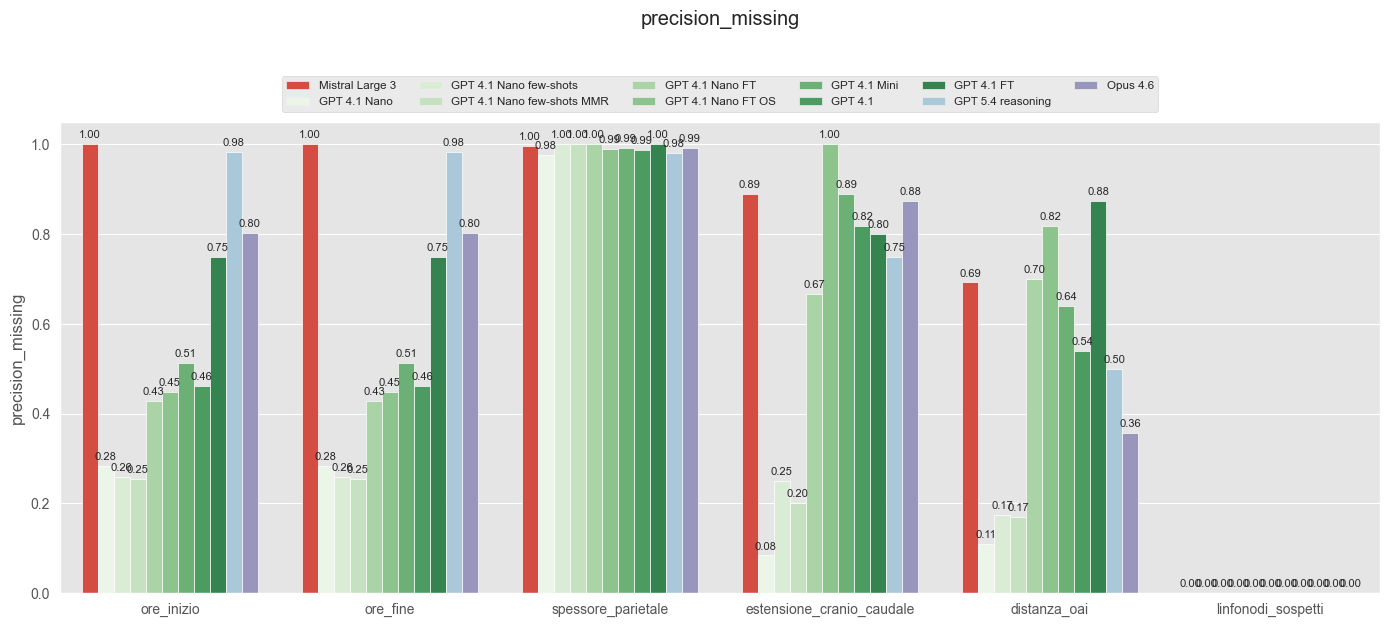

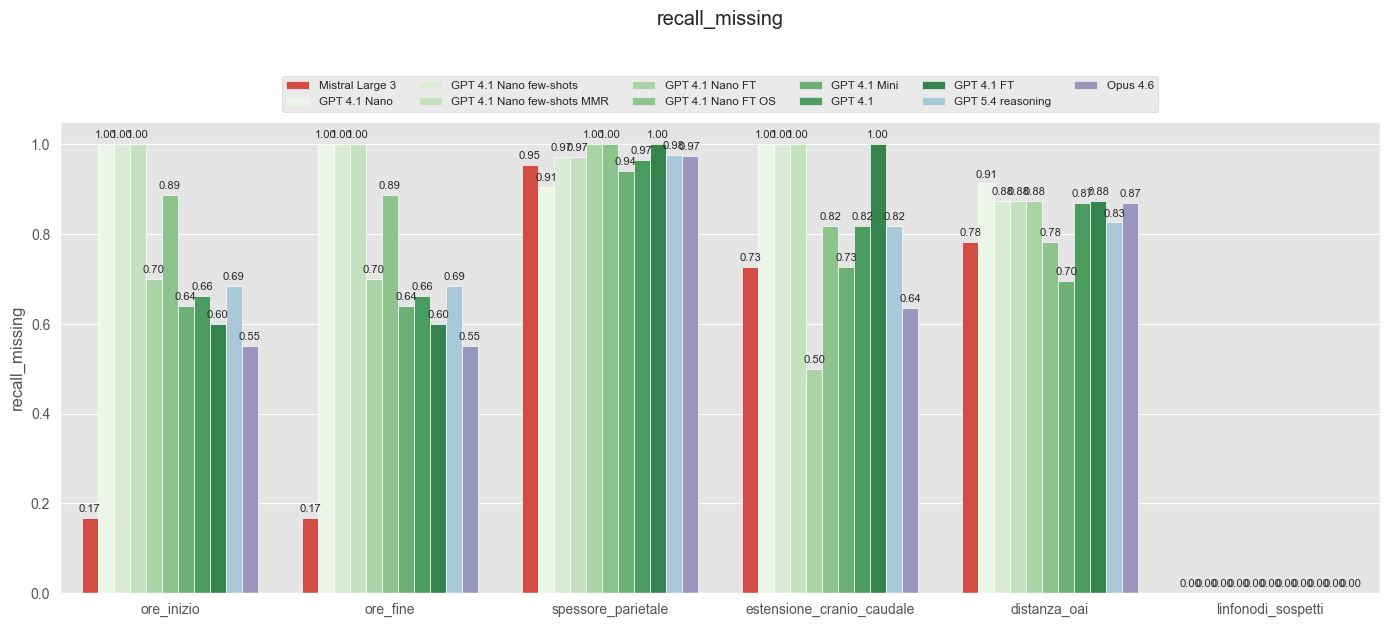

In [110]:
plot_fieds = reg_fields

plot_grouped_barchart(plot_fieds, plot_models, metric='mape')
plot_grouped_barchart(plot_fieds, plot_models, metric='mae')
plot_grouped_barchart(plot_fieds, plot_models, metric='f1_missing')
plot_grouped_barchart(plot_fieds, plot_models, metric='precision_missing')
plot_grouped_barchart(plot_fieds, plot_models, metric='recall_missing')